<a href="https://colab.research.google.com/github/replysantosh-lang/ECARComputerVissionGenAI/blob/main/cv_assignment_arpan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Preparation**

**Step 1: Annotation (CVAT)**

In [ ]:
# Dataset Annotation
# -----------------------------------------------------------
# The images were manually annotated using CVAT.
# Bounding boxes were drawn around each object belonging to
# the required defect classes.
#
# After annotation, the dataset was exported in
# YOLO Detection format.
#
# YOLO Format:
#
# <class_id> <x_center> <y_center> <width> <height>
#
# where all coordinates are normalized between 0 and 1.
#
# No Python code is required for annotation because it is
# performed manually in CVAT.

**Step 2: Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 3: Dataset Path**

In [2]:
import os

dataset_path = "/content/drive/MyDrive/pins"

print(os.listdir(dataset_path))

['test', 'valid', 'train']


**Step 4: Verify Folder Structure**

In [3]:
for folder in ["train", "valid", "test"]:
    print(f"\n{folder.upper()}")
    print(os.listdir(os.path.join(dataset_path, folder)))


TRAIN
['labels', 'images']

VALID
['labels', 'images']

TEST
['labels', 'images']


**Step 5: Count Images**

In [4]:
from glob import glob

for folder in ["train", "valid", "test"]:

    image_count = len(glob(os.path.join(dataset_path,
                                        folder,
                                        "images",
                                        "*")))

    label_count = len(glob(os.path.join(dataset_path,
                                        folder,
                                        "labels",
                                        "*.txt")))

    print(f"{folder}")
    print(f"Images : {image_count}")
    print(f"Labels : {label_count}")
    print("-"*30)

train
Images : 279
Labels : 279
------------------------------
valid
Images : 31
Labels : 31
------------------------------
test
Images : 31
Labels : 31
------------------------------


**Step 6: Verify Every Image Has a Label**

In [5]:
image_extensions = (".jpg", ".jpeg", ".png")

for folder in ["train", "valid", "test"]:

    images = glob(os.path.join(dataset_path, folder, "images", "*"))
    labels = glob(os.path.join(dataset_path, folder, "labels", "*.txt"))

    image_names = {
        os.path.splitext(os.path.basename(img))[0]
        for img in images
    }

    label_names = {
        os.path.splitext(os.path.basename(lbl))[0]
        for lbl in labels
    }

    print(f"{folder}")

    print("Missing Labels:",
          image_names - label_names)

    print("Missing Images:",
          label_names - image_names)

    print("-"*40)

train
Missing Labels: set()
Missing Images: set()
----------------------------------------
valid
Missing Labels: set()
Missing Images: set()
----------------------------------------
test
Missing Labels: set()
Missing Images: set()
----------------------------------------


**Step 7: Check Dataset Split**

In [6]:
train_images = len(glob(os.path.join(dataset_path,
                                     "train/images/*")))

valid_images = len(glob(os.path.join(dataset_path,
                                     "valid/images/*")))

test_images = len(glob(os.path.join(dataset_path,
                                    "test/images/*")))

total = train_images + valid_images + test_images

print(f"Total Images : {total}")

print(f"Train : {train_images} ({train_images/total:.2%})")
print(f"Validation : {valid_images} ({valid_images/total:.2%})")
print(f"Test : {test_images} ({test_images/total:.2%})")

Total Images : 341
Train : 279 (81.82%)
Validation : 31 (9.09%)
Test : 31 (9.09%)


**Step 8: Verify at Least 7 Bad Images in Test Set**

In [7]:
from glob import glob
import os

test_images = glob(os.path.join(dataset_path, "test/images/*"))

bad_images = sum(
    1 for img in test_images
    if os.path.basename(img).startswith("bad")
)

print("Bad Images in Test Set:", bad_images)

if bad_images >= 7:
    print("Requirement Satisfied")
else:
    print("Requirement NOT Satisfied")

Bad Images in Test Set: 19
Requirement Satisfied


In [8]:

import requests
import cv2
import matplotlib.pyplot as plt
import glob
import random
import os

In [9]:
# Function to convert bounding boxes in YOLO format to xmin, ymin, xmax, ymax.
def yolo2bbox(bboxes):
    xmin, ymin = bboxes[0]-bboxes[2]/2, bboxes[1]-bboxes[3]/2
    xmax, ymax = bboxes[0]+bboxes[2]/2, bboxes[1]+bboxes[3]/2
    return xmin, ymin, xmax, ymax

In [10]:
def plot_box(image, bboxes, labels):
    # Need the image height and width to denormalize
    # the bounding box coordinates
    h, w, _ = image.shape
    for box_num, box in enumerate(bboxes):
        x1, y1, x2, y2 = yolo2bbox(box)
        # Denormalize the coordinates.
        xmin = int(x1*w)
        ymin = int(y1*h)
        xmax = int(x2*w)
        ymax = int(y2*h)

        thickness = max(2, int(w/275))

        cv2.rectangle(
            image,
            (xmin, ymin), (xmax, ymax),
            color=(0, 0, 255),
            thickness=thickness
        )
    return image

In [11]:
# Function to plot images with the bounding boxes.
def plot(image_paths, label_paths, num_samples):
    all_images = []
    all_images.extend(glob.glob(image_paths+'/*.png'))
    all_images.extend(glob.glob(image_paths+'/*.jpg'))

    all_images.sort()

    num_images = len(all_images)

    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        j = random.randint(0,num_images-1)
        image_name = all_images[j]
        image_name = '.'.join(image_name.split(os.path.sep)[-1].split('.')[:-1])
        image = cv2.imread(all_images[j])
        with open(os.path.join(label_paths, image_name+'.txt'), 'r') as f:
            bboxes = []
            labels = []
            label_lines = f.readlines()
            for label_line in label_lines:
                label = label_line[0]
                bbox_string = label_line[2:]
                x_c, y_c, w, h = bbox_string.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        result_image = plot_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')
    plt.subplots_adjust(wspace=1)
    plt.tight_layout()
    plt.show()

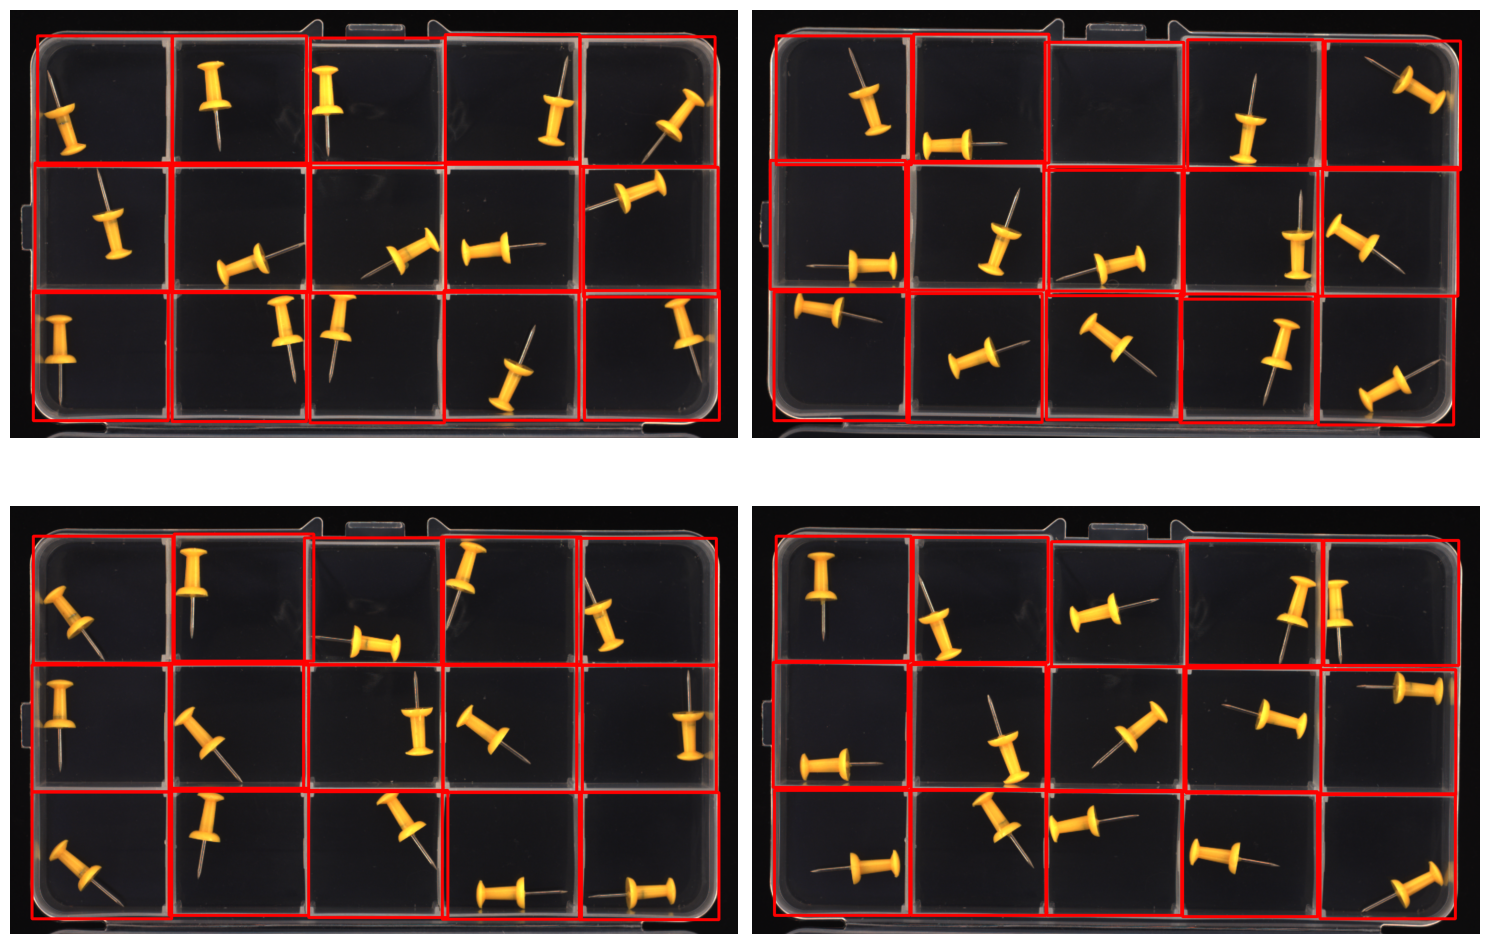

In [12]:
plot(
    image_paths='/content/drive/MyDrive/pins/train/images/',
    label_paths='/content/drive/MyDrive/pins/train/labels/',
    num_samples=4,
)

## Dataset YAML File

In [13]:
%%writefile data.yaml

# Root dataset directory
path: /content/drive/MyDrive/pins

# Image directories
train: train/images
val: valid/images
test: test/images

# Number of classes
nc: 9

# Class names
names:
  0: 1_pin
  1: 2_pin
  2: 3_pin
  3: missing_pin
  4: front_bend
  5: broken
  6: wrong_color
  7: contamination
  8: missing_separator

Writing data.yaml


In [14]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00


Experiment 1: YOLOv8 Nano (Baseline)

In [15]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="CV_Pin",
    name="YOLOv8s"
)

metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs

Experiment 2: YOLOv8 Small

In [16]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="CV_Pin",
    name="YOLOv8s"
)

metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

Experiment 3: Same architecture + Data Augmentation

In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,
    fliplr=0.5,
    mosaic=1.0,

    project="CV_Pin",
    name="YOLOv8n_Augmented"
)

metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

Experiment 4: Hyperparameter Tuning

In [18]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",

    epochs=10,
    imgsz=800,
    batch=8,
    lr0=0.005,

    project="CV_Pin",
    name="YOLOv8n_Tuned"
)
metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Tuned, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

Evaluate YOLOv8s

In [19]:
from ultralytics import YOLO

model = YOLO("runs/detect/CV_Pin/YOLOv8s/weights/best.pt")

metrics = model.val(data="data.yaml", split="test")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 4.9±2.7 MB/s, size: 1461.6 KB)
val: Scanning /content/drive/MyDrive/pins/test/labels... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 1.7it/s 18.6s
val: New cache created: /content/drive/MyDrive/pins/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2s/it 2.5s
                   all         31        462      0.852      0.556      0.485      0.432
                 1_pin         29        409      0.979          1      0.986      0.868
                 2_pin          4         19       0.85          1      0.982       0.88
                 3_pin          1          1      0.121          1      0.249      0.249
           missing_pin          5         22      0.941          1     

Evaluate YOLOv8n_Tuned

In [20]:
model = YOLO("runs/detect/CV_Pin/YOLOv8n_Tuned/weights/best.pt")

metrics = model.val(data="data.yaml", split="test")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 278.1±97.6 MB/s, size: 1462.7 KB)
val: Scanning /content/drive/MyDrive/pins/test/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 10.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.3s
                   all         31        462     0.0929          1       0.18       0.16
                 1_pin         29        409      0.772          1      0.889      0.752
                 2_pin          4         19     0.0268          1      0.127      0.103
                 3_pin          1          1   0.000502          1    0.00258   0.000734
           missing_pin          5         22     0.0239          1     0.0606      0.049
            front_bend          2          2

Evaluate YOLOv8n_Augmented

In [21]:
model = YOLO("runs/detect/CV_Pin/YOLOv8n_Augmented/weights/best.pt")

metrics = model.val(data="data.yaml", split="test")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 329.9±23.6 MB/s, size: 1450.7 KB)
val: Scanning /content/drive/MyDrive/pins/test/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 8.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2s/it 2.3s
                   all         31        462      0.987      0.111      0.204      0.177
                 1_pin         29        409      0.883          1      0.909      0.792
                 2_pin          4         19          1          0     0.0849     0.0756
                 3_pin          1          1          1          0    0.00422    0.00379
           missing_pin          5         22          1          0      0.806      0.697
            front_bend          2          2 

In [22]:
model = YOLO("runs/detect/CV_Pin/YOLOv8s-2/weights/best.pt")

metrics = model.val(data="data.yaml", split="test")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 337.4±24.0 MB/s, size: 1460.3 KB)
val: Scanning /content/drive/MyDrive/pins/test/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 4.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.1s
                   all         31        462      0.852      0.556      0.485      0.432
                 1_pin         29        409      0.979          1      0.986      0.868
                 2_pin          4         19       0.85          1      0.982       0.88
                 3_pin          1          1      0.121          1      0.249      0.249
           missing_pin          5         22      0.941          1      0.995      0.866
            front_bend          2          

Step 1: Load the Best Model

In [23]:
from ultralytics import YOLO

model = YOLO("runs/detect/CV_Pin/YOLOv8n_Tuned/weights/best.pt")

Step 2: Evaluate on the Test Set

In [24]:
metrics = model.val(
    data="data.yaml",
    split="test",
    save=True
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 335.6±49.0 MB/s, size: 1458.7 KB)
val: Scanning /content/drive/MyDrive/pins/test/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 9.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3s/it 2.6s
                   all         31        462     0.0929          1       0.18       0.16
                 1_pin         29        409      0.772          1      0.889      0.752
                 2_pin          4         19     0.0268          1      0.127      0.103
                 3_pin          1          1   0.000502          1    0.00258   0.000734
           missing_pin          5         22     0.0239          1     0.0606      0.049
            front_bend          2          2 

Step 3: Print Performance Metrics

In [25]:
print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

mAP50      : 0.1801
mAP50-95   : 0.1598
Precision  : 0.0929
Recall     : 1.0000


Step 4: Precision–Recall Curve

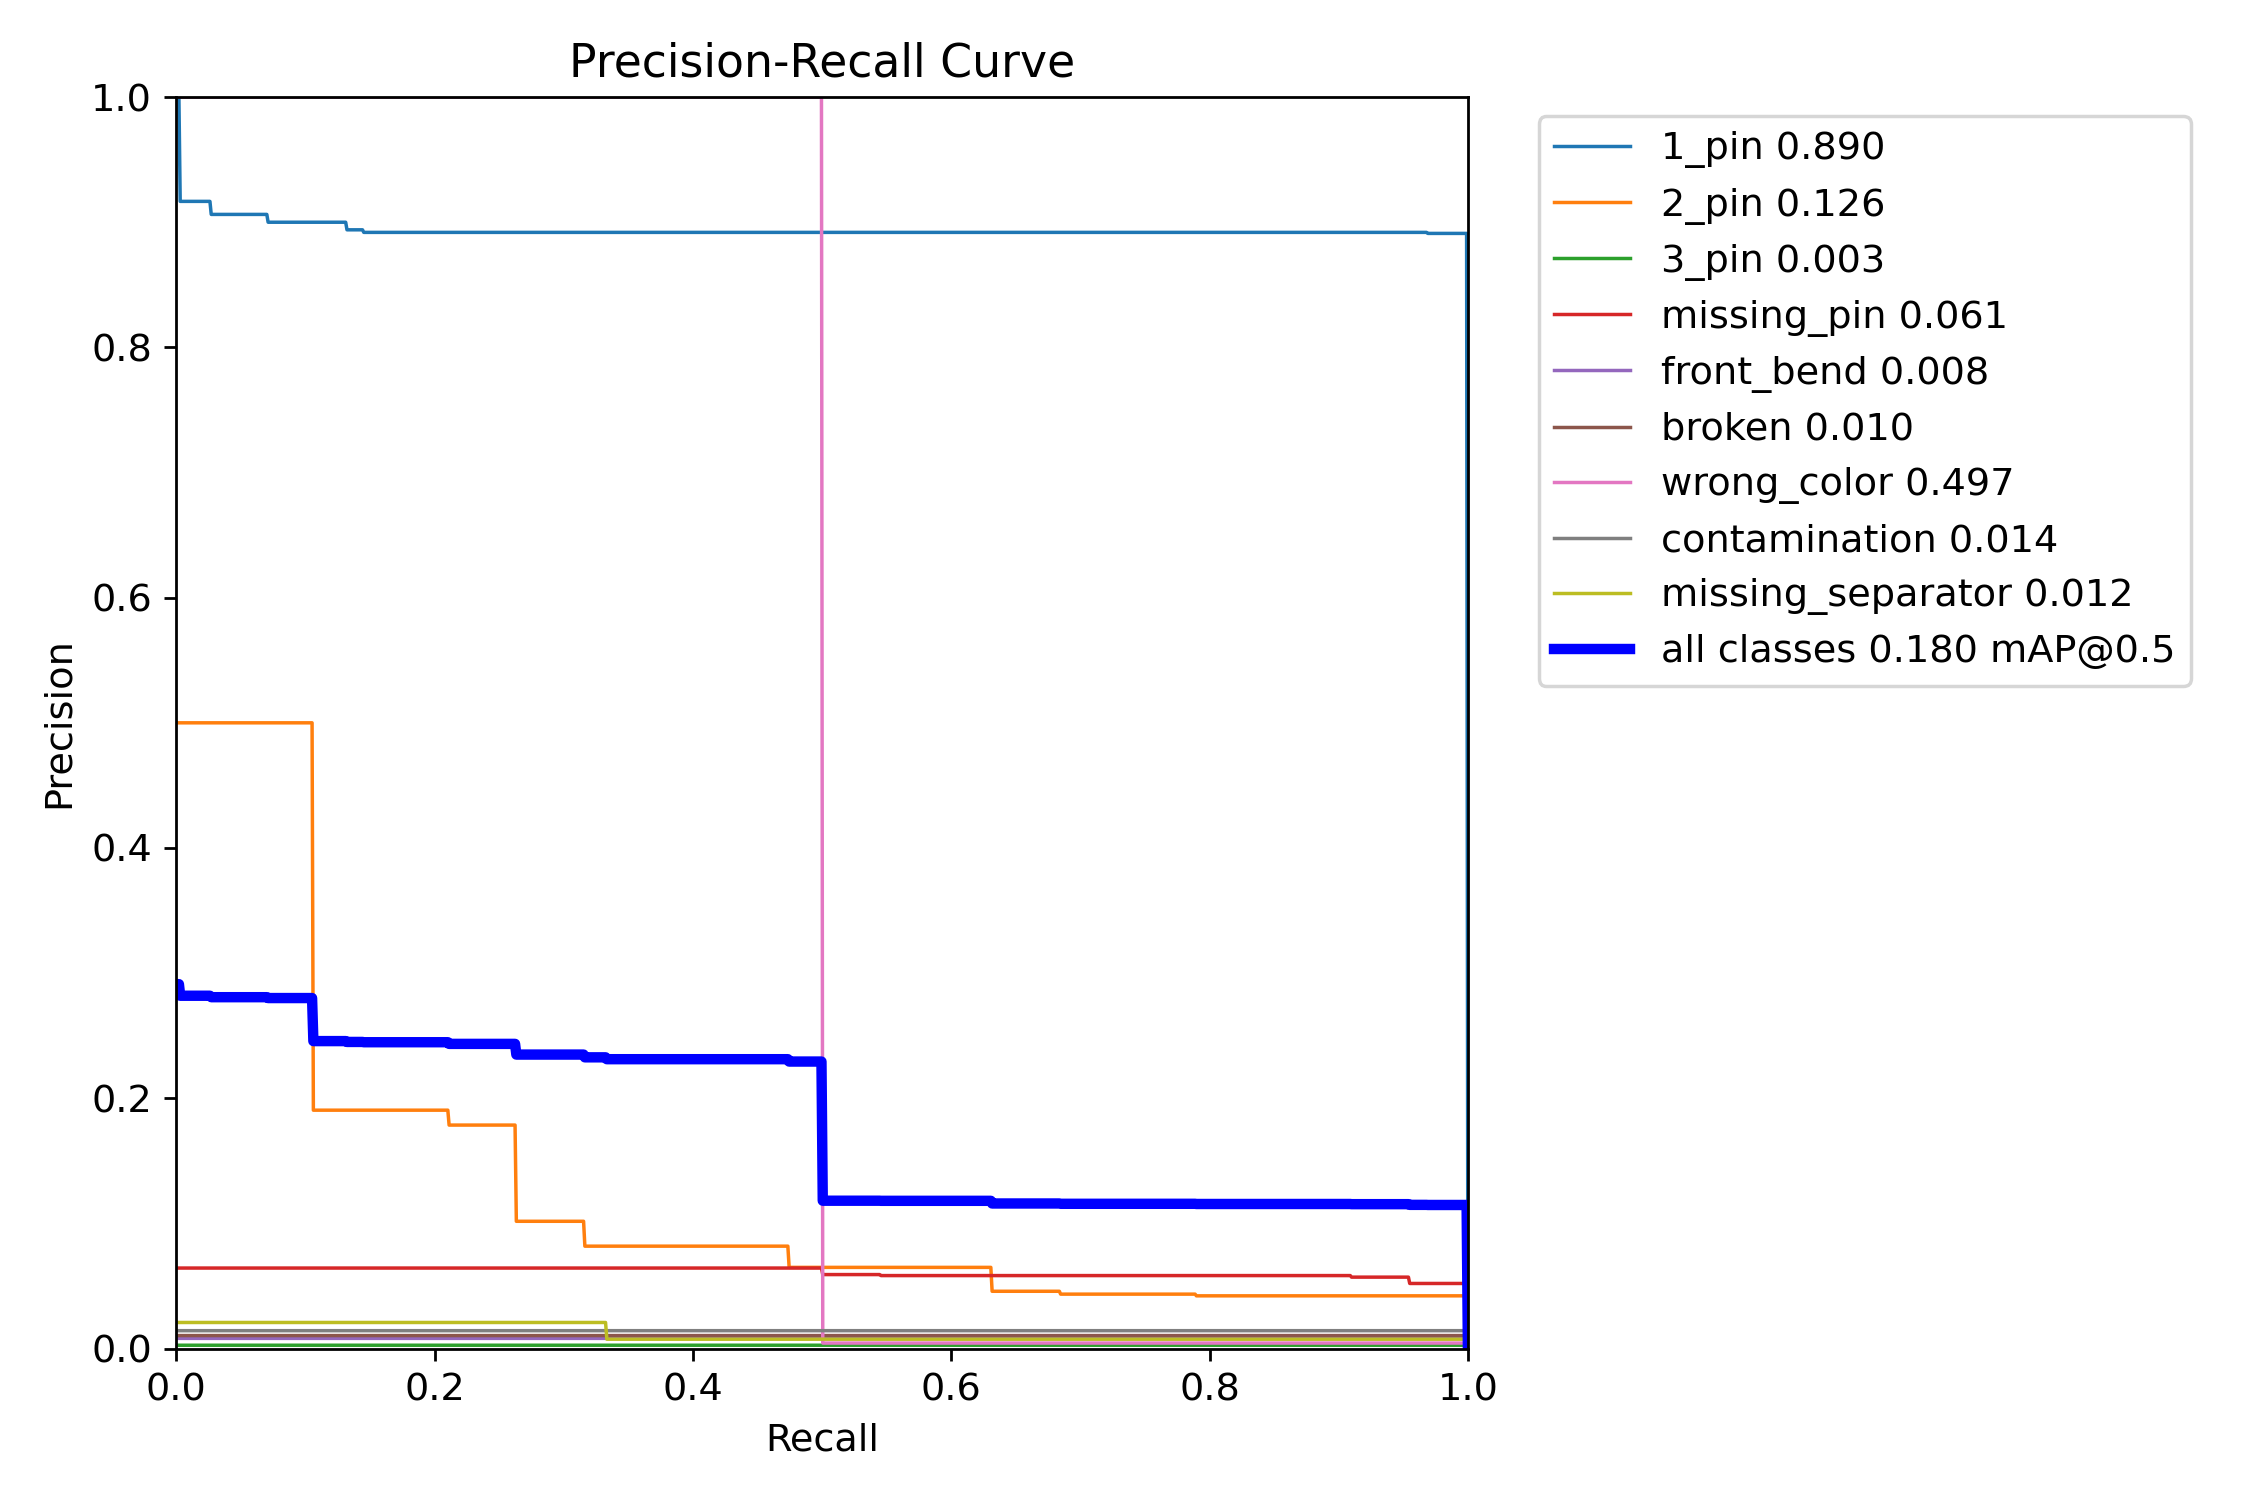

In [26]:
from IPython.display import Image

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxPR_curve.png")

Step 5: Confusion Matrix

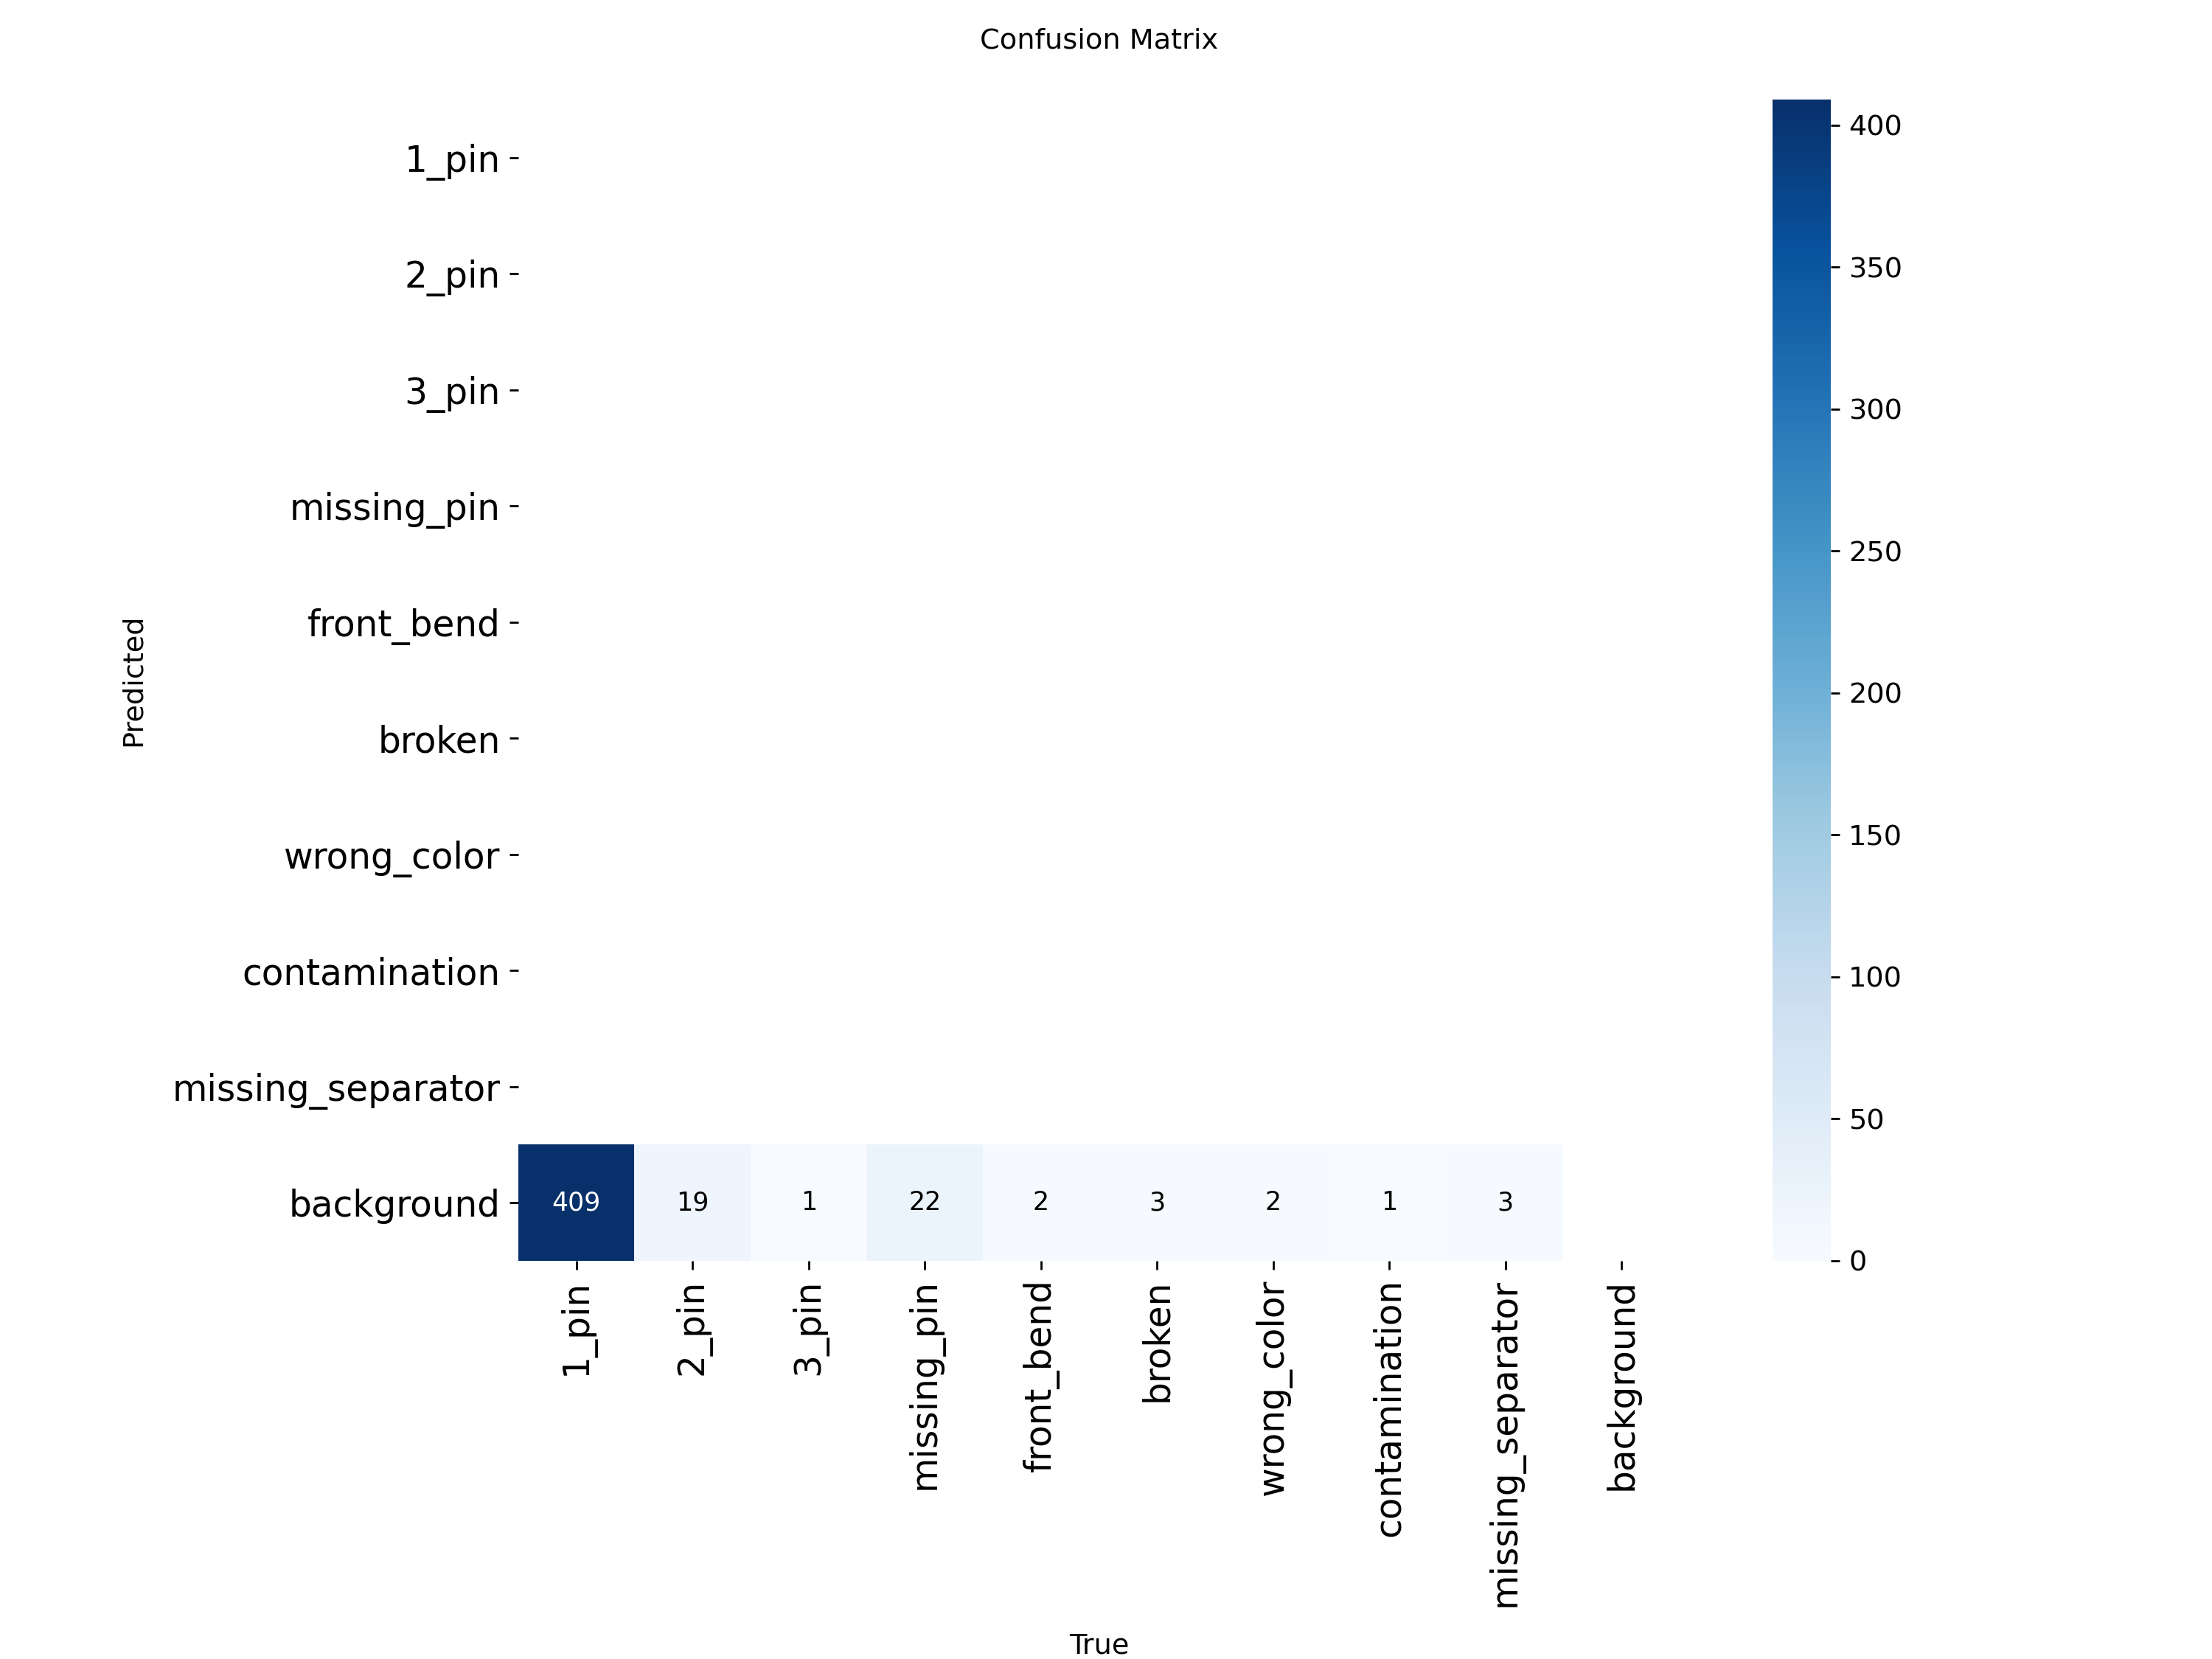

In [27]:
from IPython.display import Image

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/confusion_matrix.png")

Step 6: Other Useful Curves

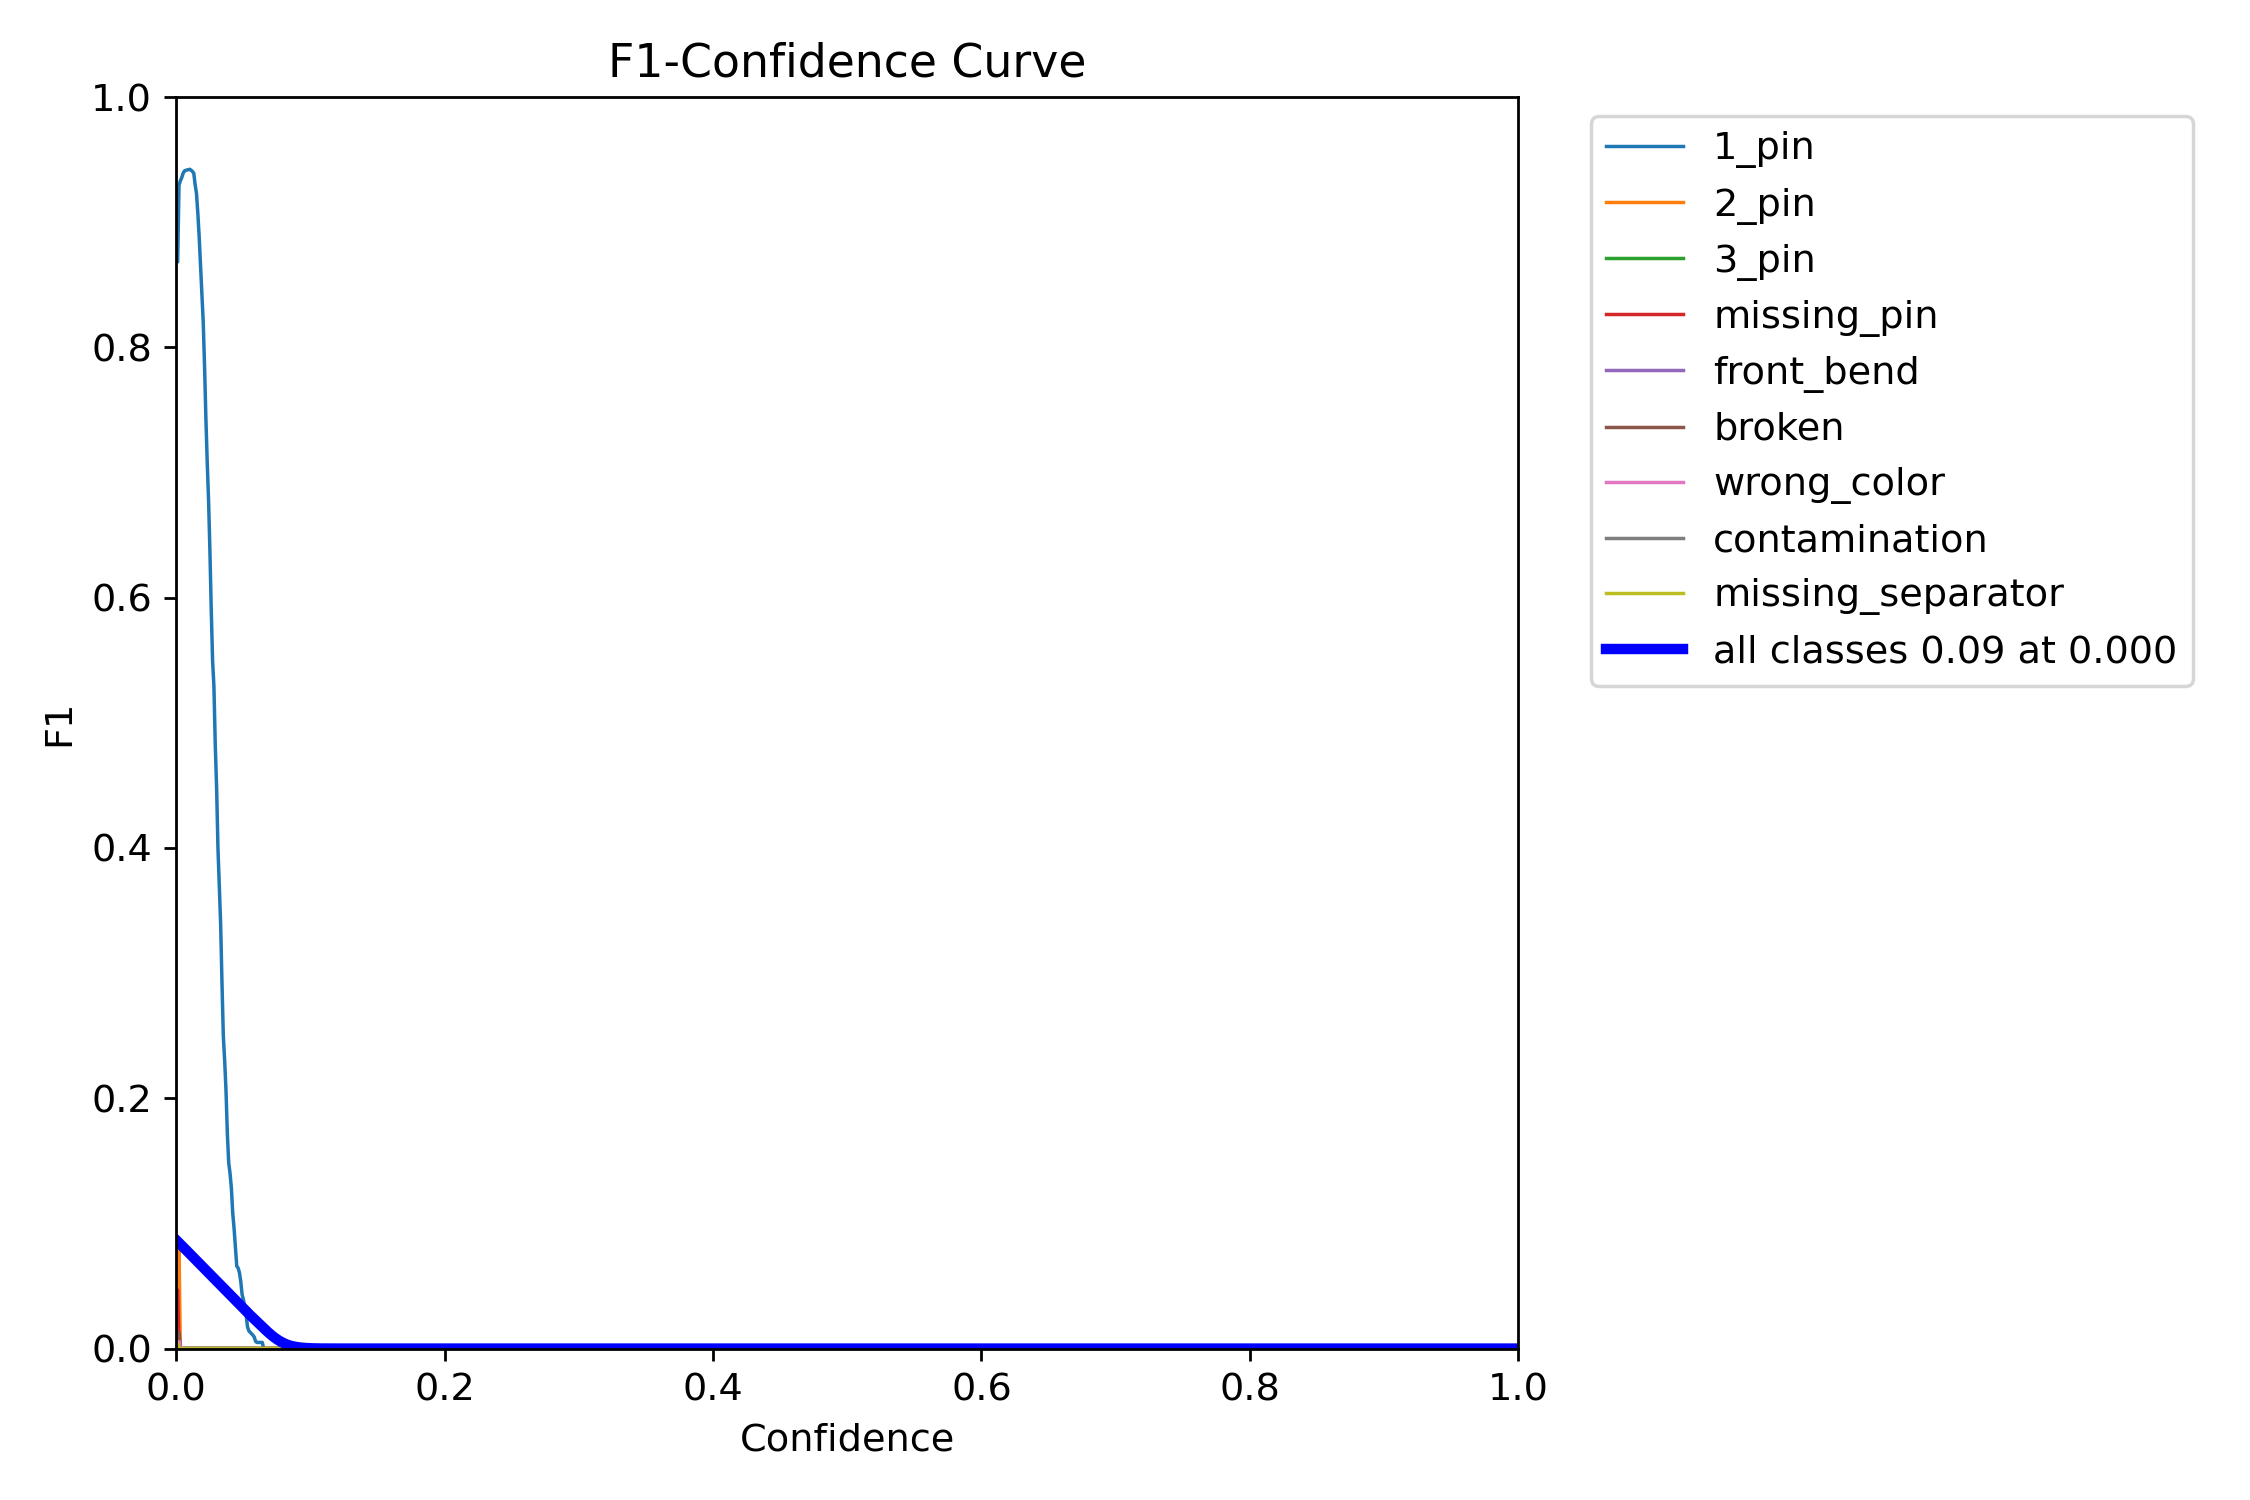

In [28]:
from IPython.display import Image

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxF1_curve.png")

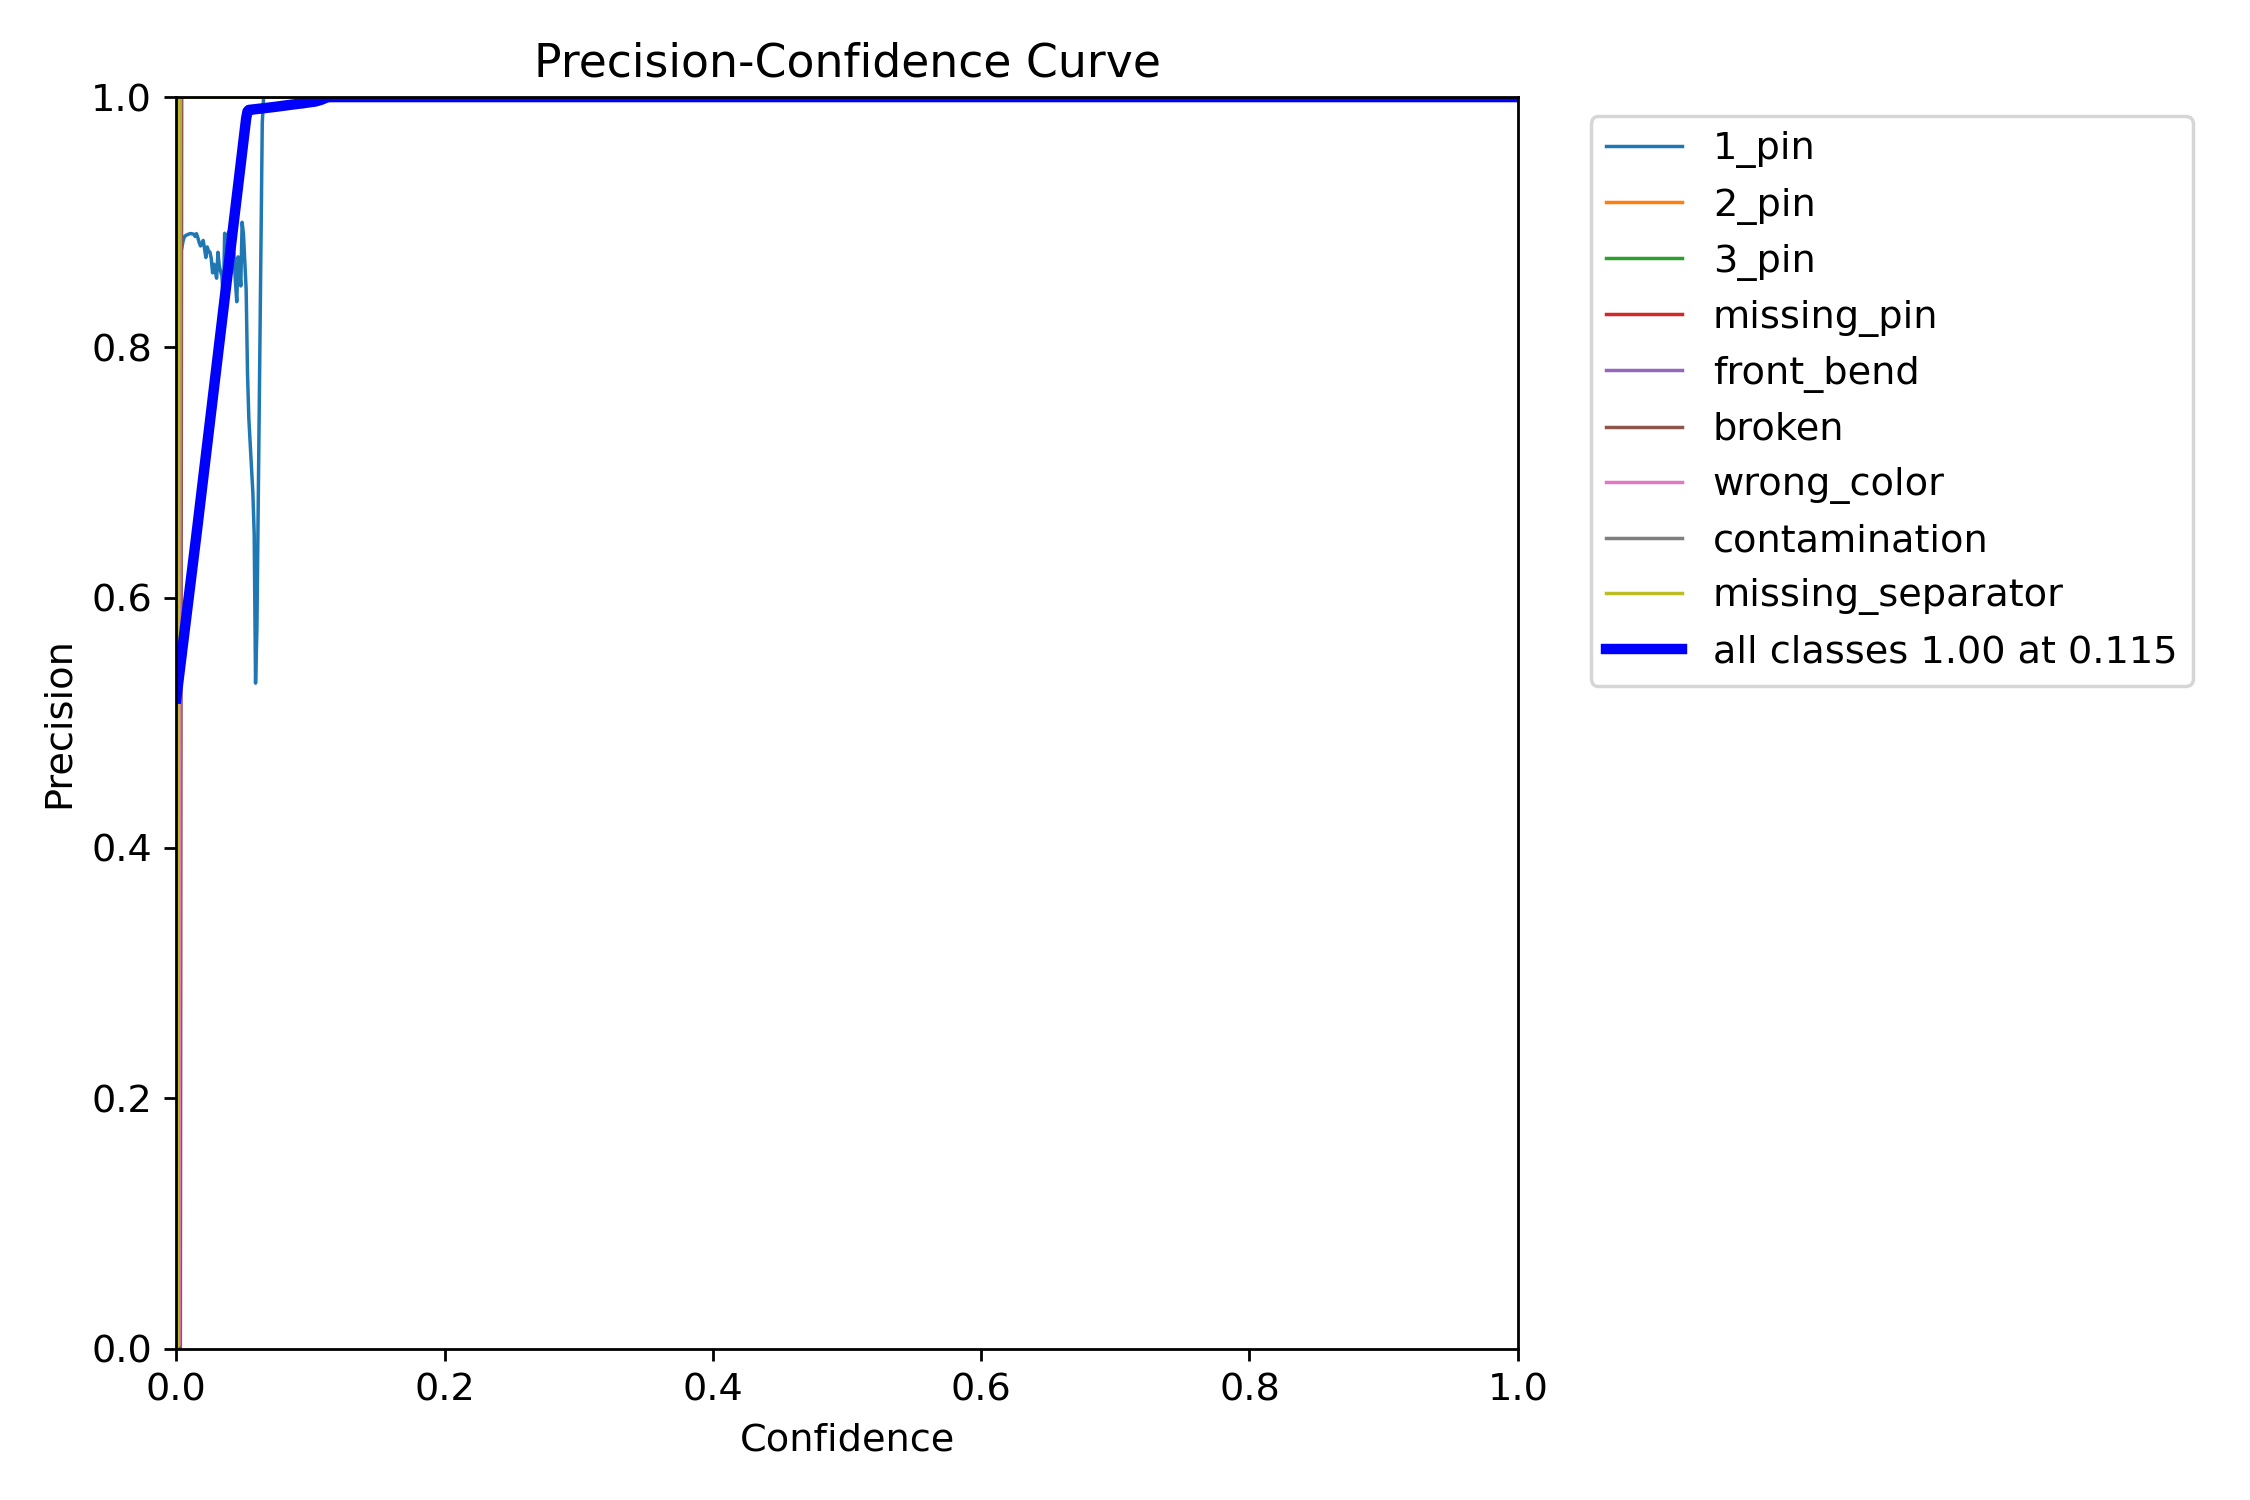

In [29]:
Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxP_curve.png")

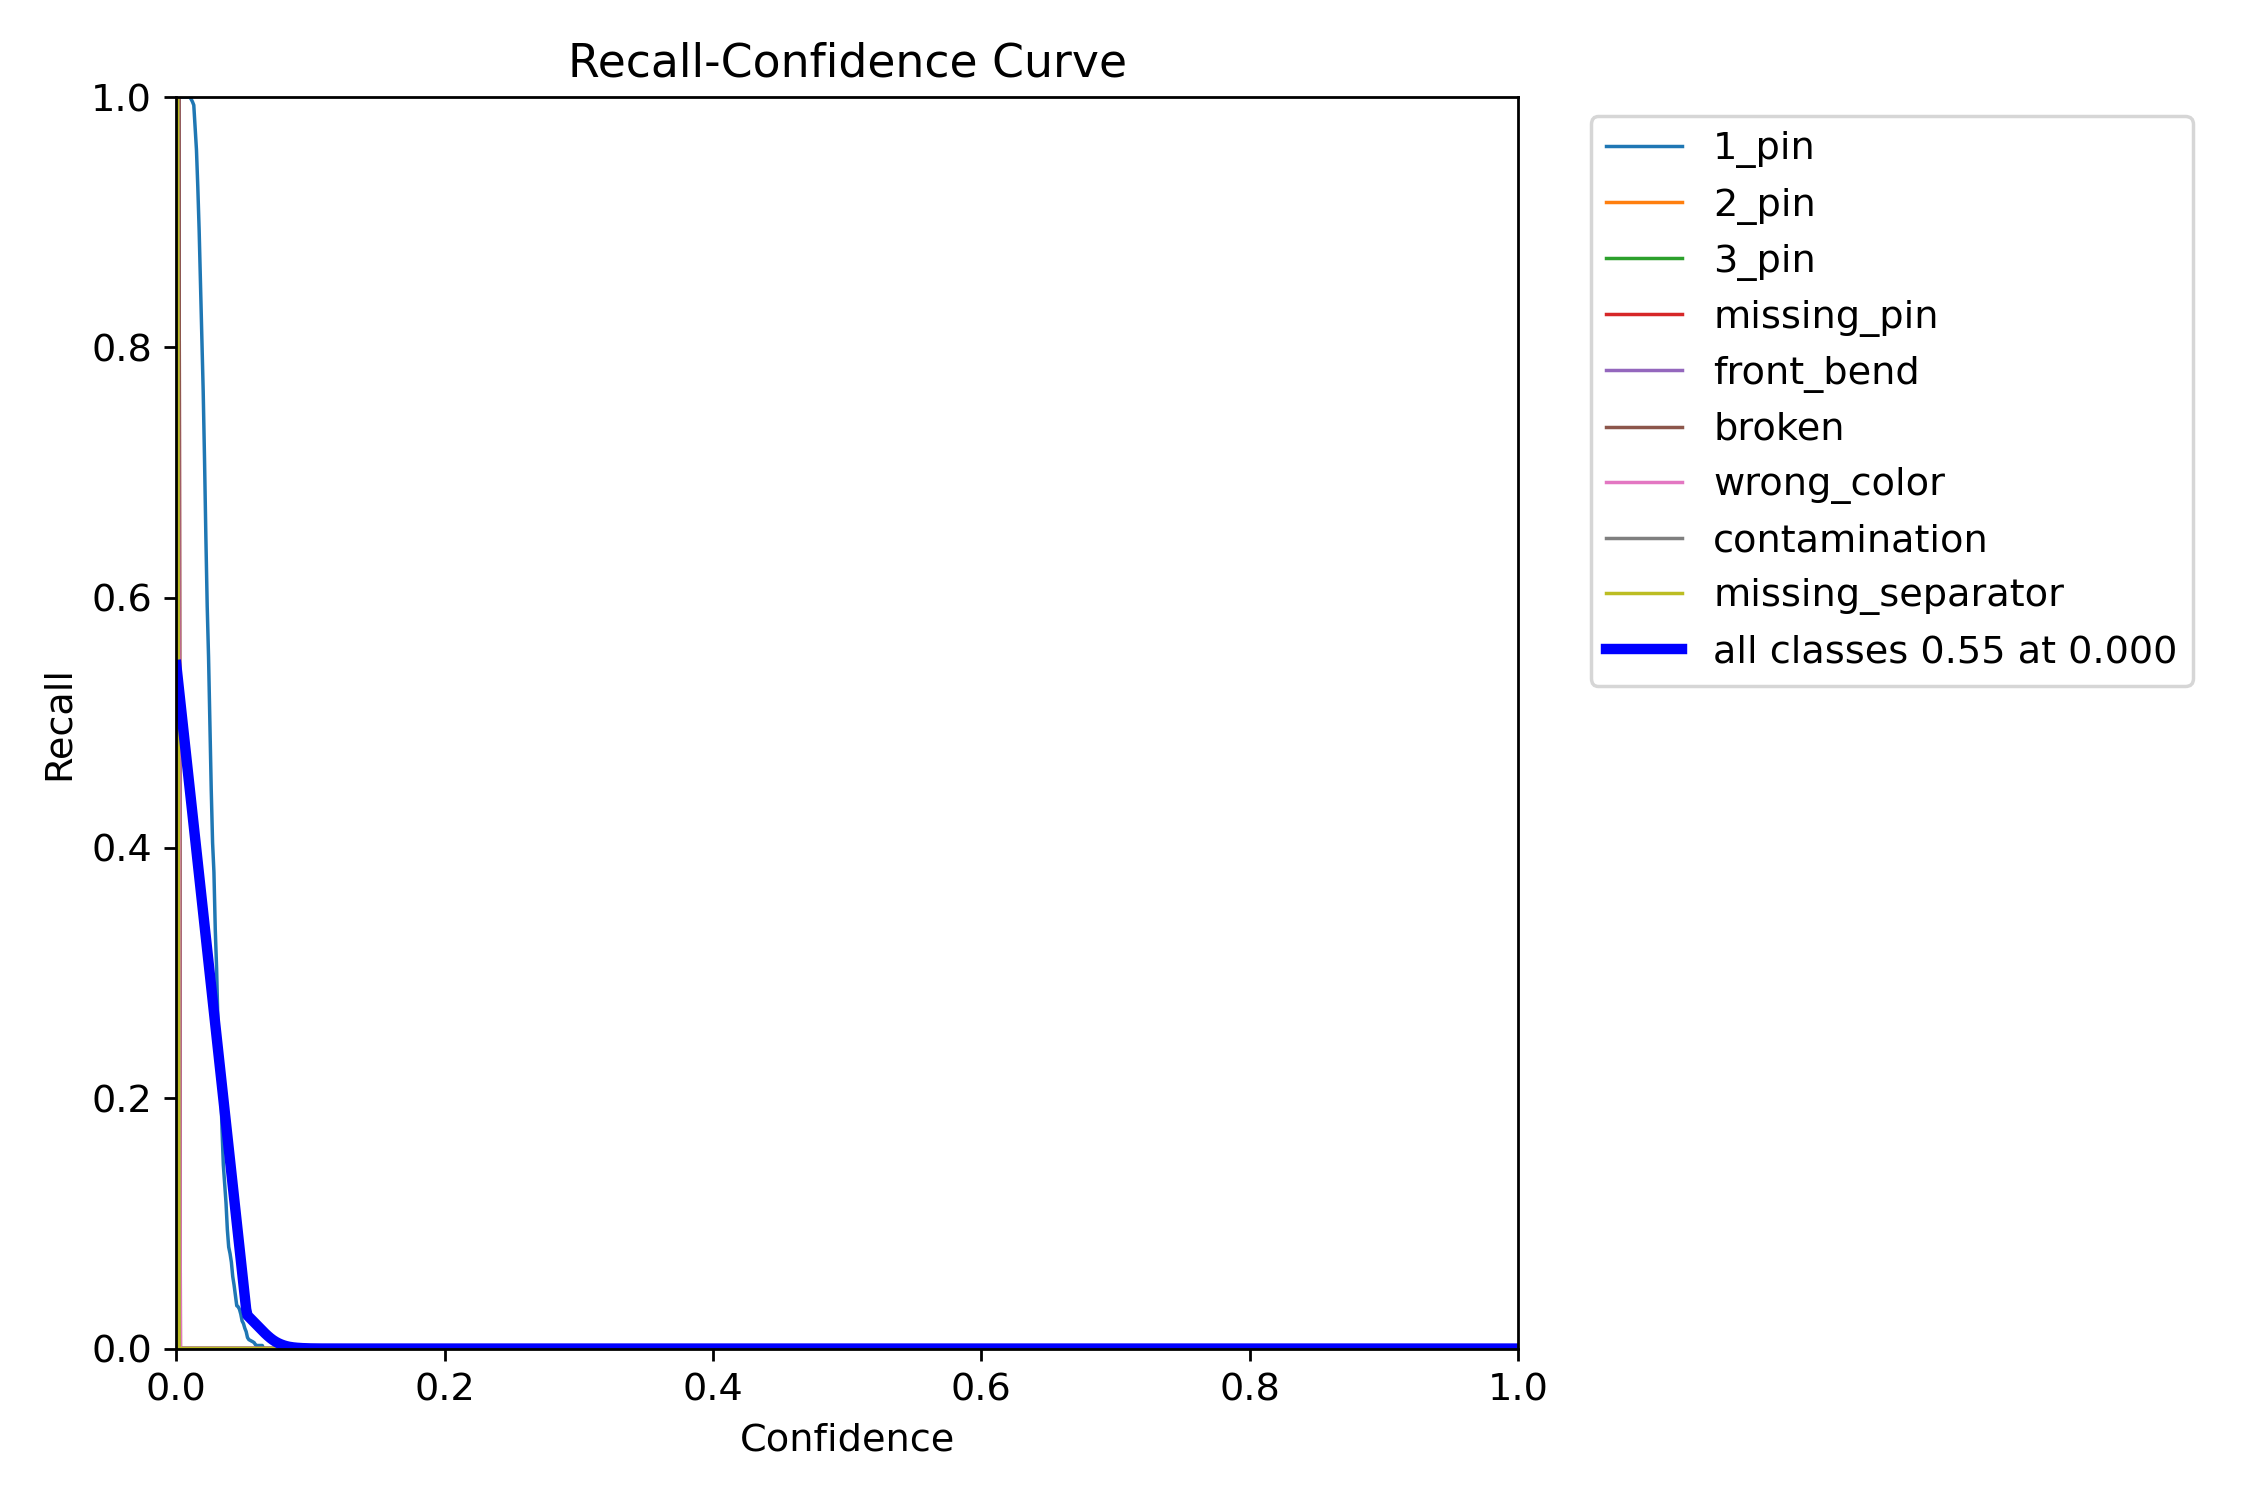

In [30]:
Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxR_curve.png")

In [31]:
def accept_reject(results):

    good_count = 0
    bad_count = 0

    for result in results:

        classes = result.boxes.cls.cpu().numpy()
        print(classes)

        for cls in classes:

            if int(cls) == 0:      # Good
                good_count += 1

            elif int(cls) == 1:    # Bad
                bad_count += 1

    print(f"Good Pins : {good_count}")
    print(f"Bad Pins  : {bad_count}")

    # Decision Logic
    if good_count == 15 and bad_count == 0:
        decision = "ACCEPT"
    else:
        decision = "REJECT"

    print(f"\nDecision : {decision}")

    return decision

In [32]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO("runs/detect/CV_Pin/YOLOv8n_Tuned/weights/best.pt")

# Predict on the test images
results = model.predict(
    source="/content/drive/MyDrive/CV_pin_dataset/test/images",
    conf=0.10,
    save=True
)

# Class names
class_names = model.names

def accept_reject(results, class_names):

    print("=" * 70)

    for result in results:

        # Count detected objects in one image
        counts = {}

        for cls in result.boxes.cls.tolist():

            cls_name = class_names[int(cls)]
            counts[cls_name] = counts.get(cls_name, 0) + 1

        # Count good pins
        good_pins = (
            counts.get("1_pin", 0) +
            counts.get("2_pin", 0) +
            counts.get("3_pin", 0)
        )

        # Count bad pins / defects
        bad_pins = (
            counts.get("front_bend", 0) +
            counts.get("broken", 0) +
            counts.get("wrong_color", 0) +
            counts.get("contamination", 0) +
            counts.get("missing_pin", 0) +
            counts.get("missing_separator", 0)
        )

        # Decision Logic
        if good_pins == 15 and bad_pins == 0:
            decision = "ACCEPT"
        else:
            decision = "REJECT"

        # Display Results
        print(f"\nImage      : {result.path}")
        print(f"Detections : {counts}")
        print(f"Good Pins  : {good_pins}")
        print(f"Bad Pins   : {bad_pins}")
        print(f"Decision   : {decision}")
        print("-" * 70)


# Run the method
accept_reject(results, class_names)


image 1/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_026.png: 480x800 (no detections), 41.7ms
image 2/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_027.png: 480x800 (no detections), 7.7ms
image 3/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_028.png: 480x800 (no detections), 8.1ms
image 4/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_044.png: 480x800 (no detections), 8.2ms
image 5/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_063.png: 480x800 (no detections), 8.4ms
image 6/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_064.png: 480x800 (no detections), 9.1ms
image 7/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_079.png: 480x800 (no detections), 7.2ms
image 8/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_080.png: 480x800 (no detections), 7.2ms
image 9/33 /content/drive/MyDrive/CV_pin_dataset/test/images/bad_091.png: 480x800 (no detections), 7.2ms
image 10/33 /content/drive/MyDrive/CV_pin_dataset/tes

In [34]:
import os

label = "/content/drive/MyDrive/pins/train/labels/good_136.txt"

with open(label) as f:
    print(f.read())

0 0.125535 0.216795 0.191659 0.296990
0 0.127747 0.507520 0.191659 0.297000
0 0.127747 0.803260 0.191659 0.297000
0 0.316456 0.214285 0.191653 0.296990
0 0.318668 0.511280 0.191653 0.297000
0 0.314979 0.802005 0.191653 0.296990
0 0.505162 0.208020 0.191653 0.297000
0 0.506635 0.498745 0.191659 0.296990
0 0.508109 0.796995 0.191653 0.296990
0 0.688709 0.213035 0.191653 0.296990
0 0.690182 0.510025 0.191659 0.296990
0 0.694606 0.804515 0.191659 0.296990
0 0.880365 0.213035 0.191659 0.296990
0 0.879626 0.503760 0.191653 0.297000
0 0.881838 0.799500 0.191653 0.297000



In [35]:
print(model.names)

{0: '1_pin', 1: '2_pin', 2: '3_pin', 3: 'missing_pin', 4: 'front_bend', 5: 'broken', 6: 'wrong_color', 7: 'contamination', 8: 'missing_separator'}


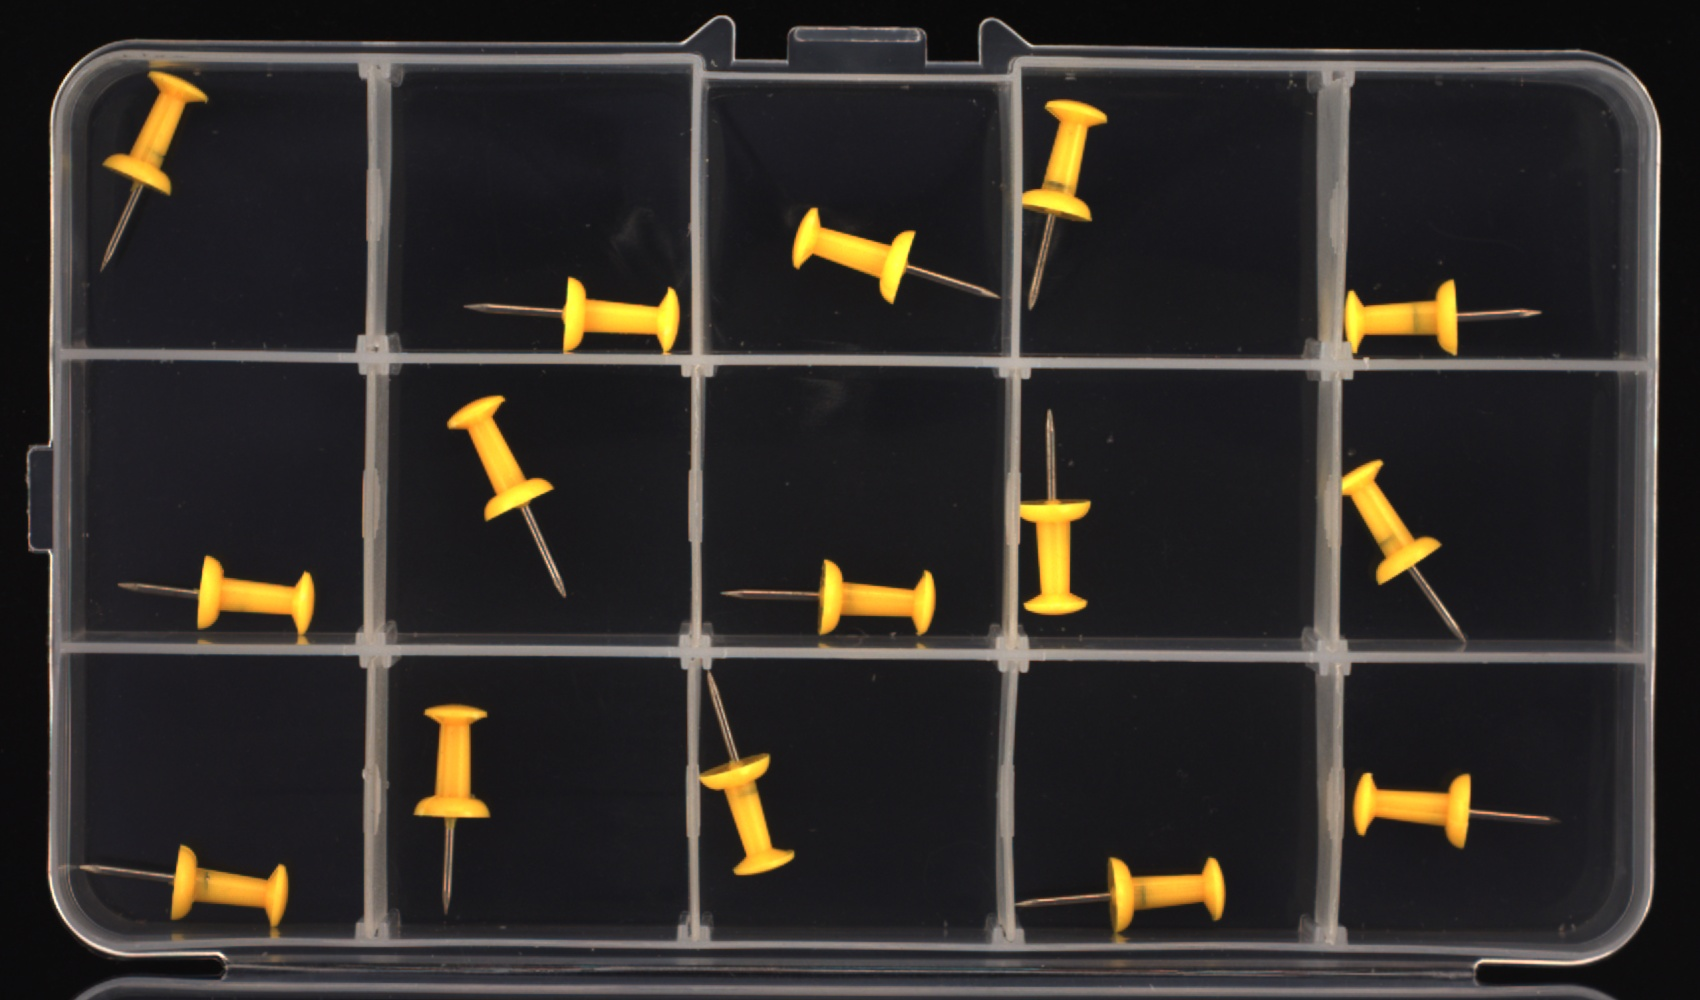

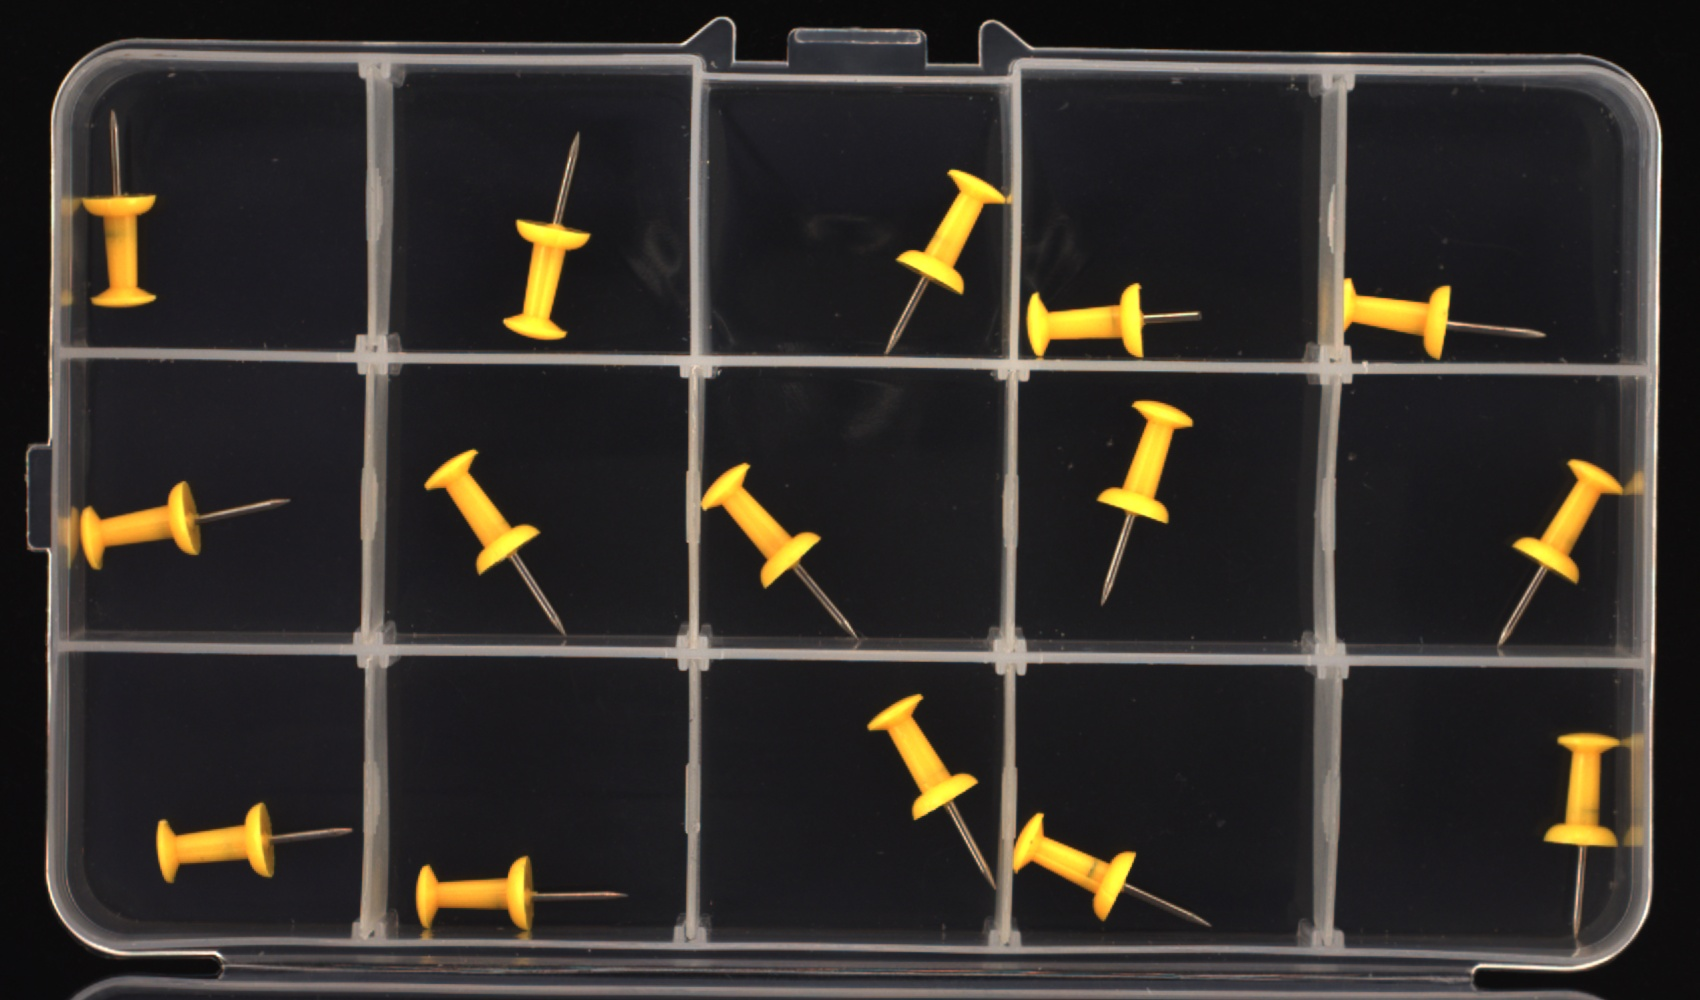

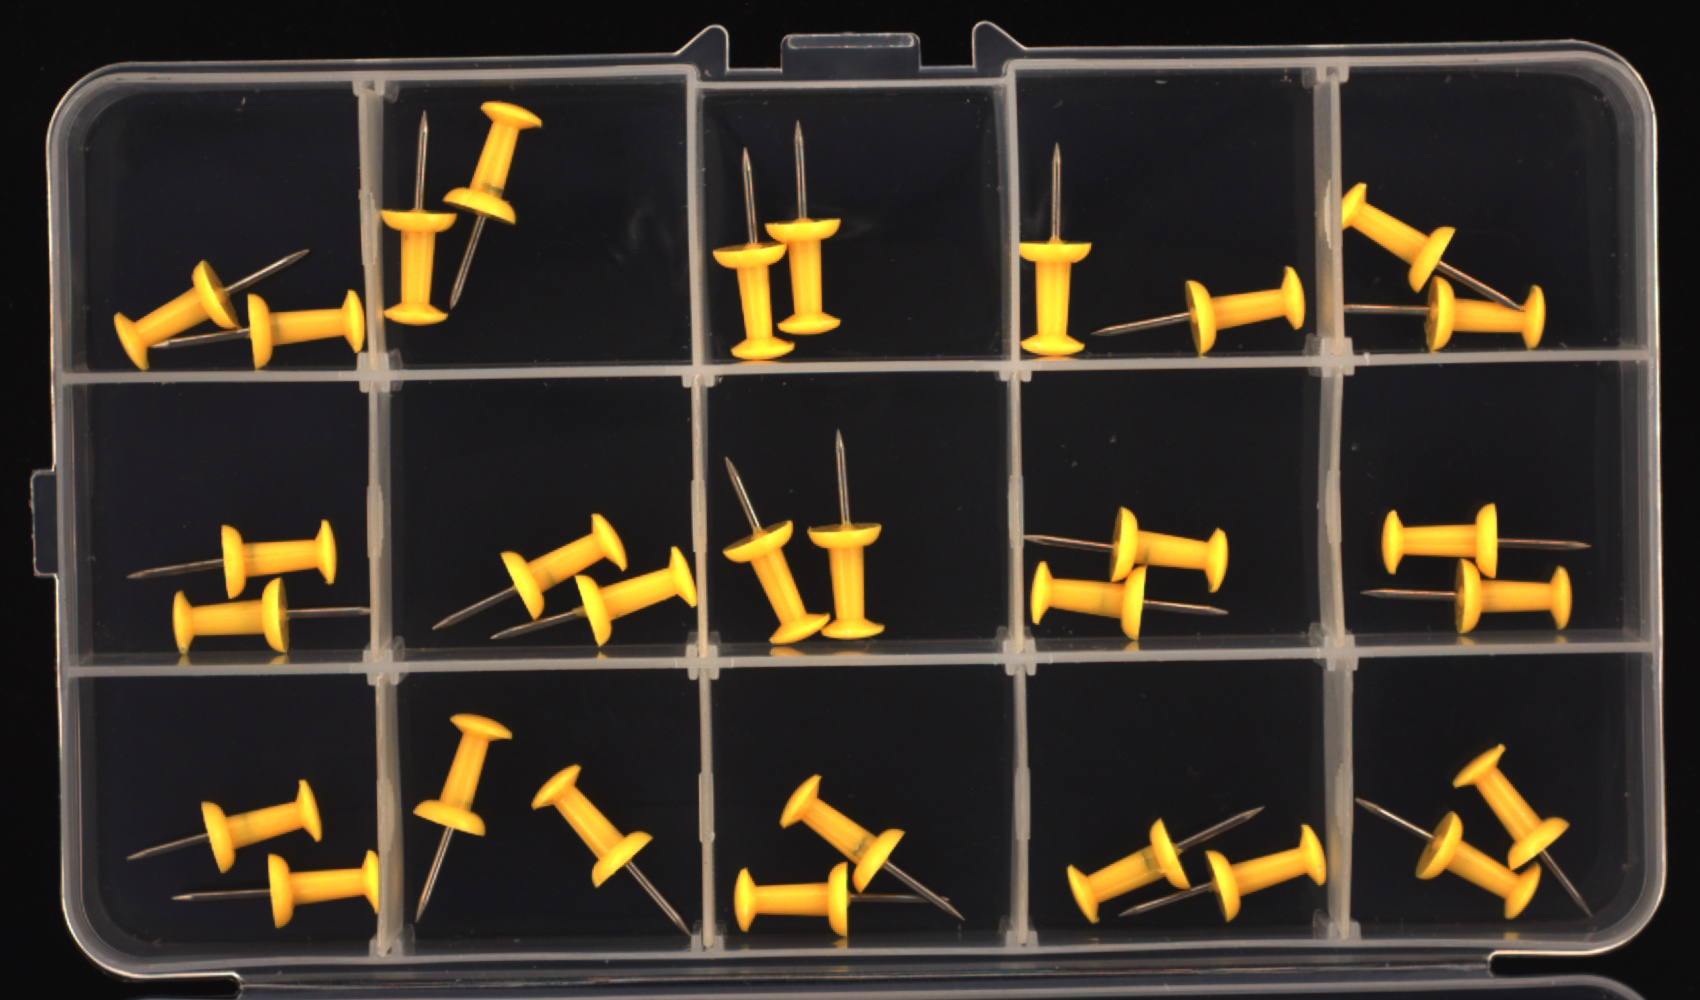

In [38]:
from IPython.display import Image, display

display(Image("/content/runs/detect/predict/good_070.jpg"))
display(Image("/content/runs/detect/predict/bad_026.jpg"))
display(Image("/content/runs/detect/predict/bad_103.jpg"))

